In [1]:
import sys
print(sys.executable)


/Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/.venv311/bin/python


In [2]:
%pip install -U pip
%pip install geopandas pyproj shapely fiona pandas pyarrow matplotlib pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import sys

# ---------------- Paths (auto-detect) ----------------

PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"/"geoparquet"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2015, 2025))  # 2015 → 2024

print("✅ Project root:", PROJECT_ROOT)
print("📂 Data dir:", DATA_DIR)
print("📊 Figures dir:", FIG_DIR)
print("🐍 Python:", sys.version)

✅ Project root: /Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis
📂 Data dir: /Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/data/geoparquet
📊 Figures dir: /Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/figures
🐍 Python: 3.11.9 (main, Nov 12 2025, 23:51:42) [Clang 15.0.0 (clang-1500.1.0.2.5)]


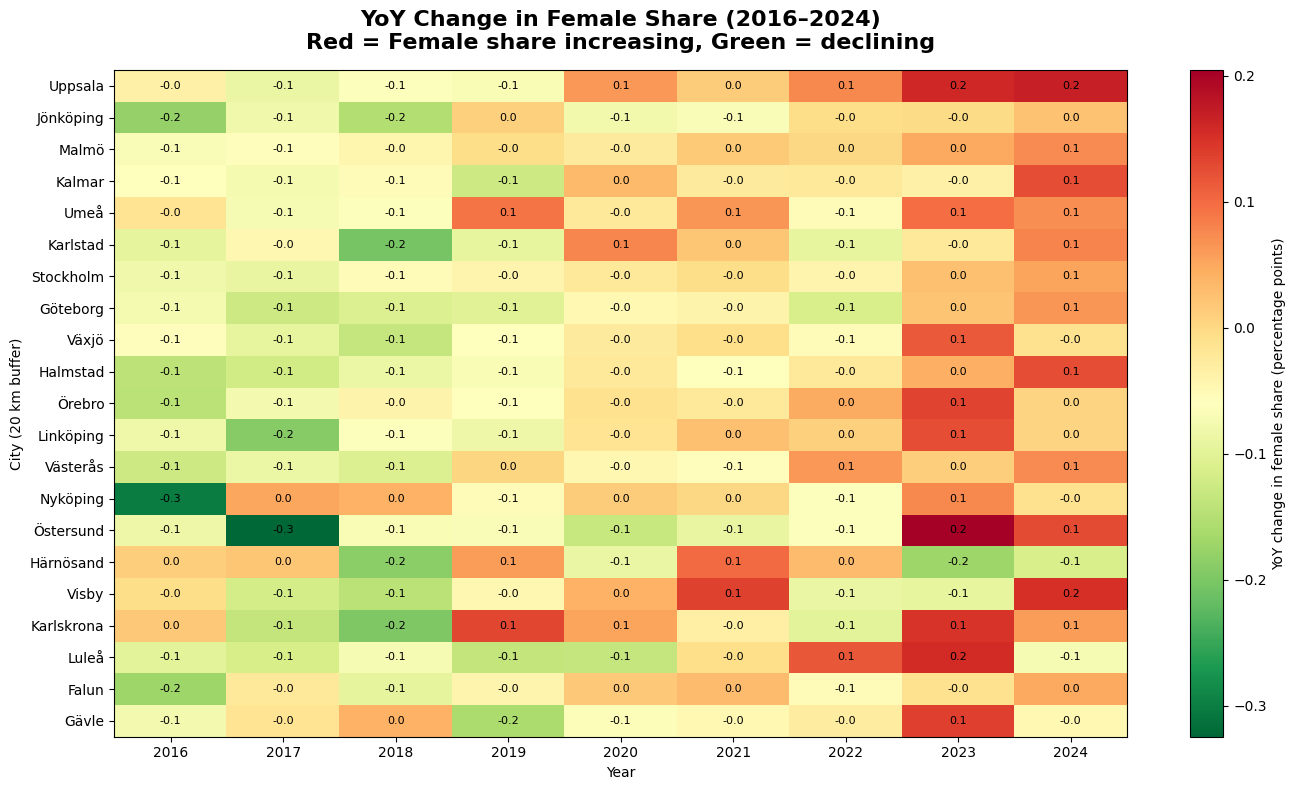

In [33]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "geoparquet"

YEARS = list(range(2015, 2025))   # 2015–2024
RADIUS_KM = 20
RADIUS_M = RADIUS_KM * 1000

FEMALE_COL = "kvinna"
MALE_COL   = "man"

# 21 major Swedish cities with WGS84 coordinates
cities = {
    "Uppsala":    (17.6389, 59.8586),
    "Jönköping":  (14.1618, 57.7826),
    "Malmö":      (13.0038, 55.6050),
    "Kalmar":     (16.3568, 56.6634),
    "Umeå":       (20.2653, 63.8258),
    "Karlstad":   (13.5036, 59.4022),
    "Stockholm":  (18.0686, 59.3293),
    "Göteborg":   (11.9746, 57.7089),
    "Växjö":      (14.8059, 56.8790),
    "Halmstad":   (12.8590, 56.6745),
    "Örebro":     (15.2134, 59.2753),
    "Linköping":  (15.6216, 58.4109),
    "Västerås":   (16.5448, 59.6099),
    "Nyköping":   (17.0079, 58.7530),
    "Östersund":  (14.6357, 63.1792),
    "Härnösand":  (17.9400, 62.6323),
    "Visby":      (18.2920, 57.6348),
    "Karlskrona": (15.5866, 56.1616),
    "Luleå":      (22.1567, 65.5848),
    "Falun":      (15.6350, 60.6074),
    "Gävle":      (17.1413, 60.6749),
}
city_names = list(cities.keys())

# ----------------------------------------------------
# 1. Load merged 2015–2024 GeoParquet file
# ----------------------------------------------------
merged_path = DATA_DIR / "befolkning_1km_2015_2024.parquet"
gdf_all = gpd.read_parquet(merged_path).copy()

# Ensure CRS (original data is in WGS84)
gdf_all = gdf_all.set_crs(4326)

# Validate gender columns
if FEMALE_COL not in gdf_all.columns or MALE_COL not in gdf_all.columns:
    raise ValueError(
        f"Cannot find gender columns {FEMALE_COL}/{MALE_COL}. "
        f"Columns available: {gdf_all.columns.tolist()}"
    )

# Create gender population variables
gdf_all["female_pop"] = gdf_all[FEMALE_COL]
gdf_all["male_pop"]   = gdf_all[MALE_COL]

# Create total population if missing
if "total_pop" in gdf_all.columns:
    gdf_all["total_pop"] = gdf_all["total_pop"]
elif "beftotalt" in gdf_all.columns:
    gdf_all["total_pop"] = gdf_all["beftotalt"]
else:
    gdf_all["total_pop"] = gdf_all["female_pop"] + gdf_all["male_pop"]

# Reproject once to SWEREF 3006 for spatial operations
gdf_all_3006 = gdf_all.to_crs(3006)

# ----------------------------------------------------
# 2. Construct 20 km buffers around each city
# ----------------------------------------------------
city_points = gpd.GeoDataFrame(
    {
        "city": city_names,
        "lon": [cities[c][0] for c in city_names],
        "lat": [cities[c][1] for c in city_names],
    },
    geometry=[Point(cities[c][0], cities[c][1]) for c in city_names],
    crs=4326,
).to_crs(3006)

# Replace points with 20 km buffer geometries
city_points["geometry"] = city_points.geometry.buffer(RADIUS_M)

# ----------------------------------------------------
# 3. Compute female-share per city and year
# ----------------------------------------------------
records = []

for _, city_row in city_points.iterrows():
    city_name = city_row["city"]
    buf_geom = city_row["geometry"]

    # Extract all 1 km cells inside the city's 20 km buffer for all years
    in_buf = gdf_all_3006[gdf_all_3006.geometry.within(buf_geom)].copy()

    # If no grids fall inside the buffer, fill years with NaN
    if in_buf.empty:
        for y in YEARS:
            records.append(
                {"city": city_name, "year": y, "female_share": np.nan}
            )
        continue

    # Aggregate by year
    grp = (
        in_buf.groupby("year")[["female_pop", "total_pop"]]
        .sum()
        .reset_index()
    )

    # Compute female share (% of total population)
    grp["female_share"] = grp["female_pop"] / grp["total_pop"].replace(0, np.nan)
    grp["city"] = city_name

    # Save records
    records.extend(grp[["city", "year", "female_share"]].to_dict("records"))

df_share = pd.DataFrame(records)

# ----------------------------------------------------
# 4. Compute YoY change in female share (percentage points)
# ----------------------------------------------------
df_share = df_share.sort_values(["city", "year"])

# Convert to percentage
df_share["female_share_pct"] = df_share["female_share"] * 100

# YoY change in percentage points
df_share["female_share_yoy"] = df_share.groupby("city")["female_share_pct"].diff()

# Keep 2016–2024 (first year has no YoY)
df_yoy = df_share[df_share["year"] >= 2016].copy()

# Pivot into City × Year heatmap matrix
heat_data = df_yoy.pivot(index="city", columns="year", values="female_share_yoy")
heat_data = heat_data.loc[city_names]  # ensure consistent display order

# ----------------------------------------------------
# 5. Plot heatmap
# ----------------------------------------------------
years_plot = list(range(2016, 2025))

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    heat_data[years_plot].values,
    aspect="auto",
    cmap="RdYlGn_r",   # Red = female share increasing, Green = declining
)

# Axis labels
ax.set_xticks(np.arange(len(years_plot)))
ax.set_xticklabels(years_plot)

ax.set_yticks(np.arange(len(city_names)))
ax.set_yticklabels(city_names)

ax.set_xlabel("Year")
ax.set_ylabel(f"City ({RADIUS_KM} km buffer)")

ax.set_title(
    "YoY Change in Female Share (2016–2024)\n"
    "Red = Female share increasing, Green = declining",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

# Annotate each grid cell with numeric YoY value
for i, city in enumerate(city_names):
    for j, year in enumerate(years_plot):
        val = heat_data.loc[city, year]
        if pd.notna(val):
            ax.text(
                j, i, f"{val:.1f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("YoY change in female share (percentage points)", rotation=90)

plt.tight_layout()
plt.show()


✅ saved: /Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/figures/Female growth 15–24 (within 20km).png


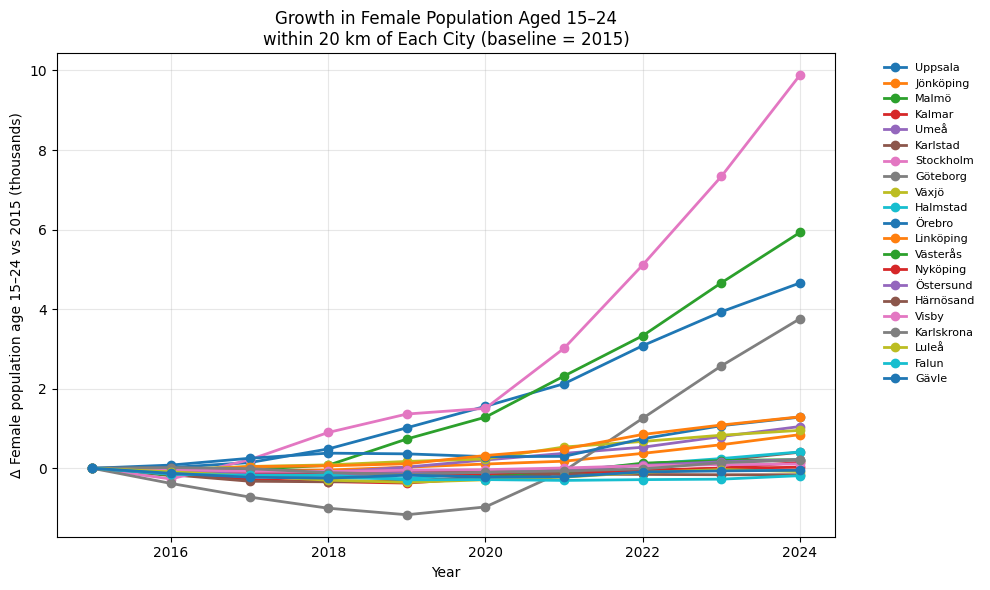

✅ saved: /Users/amandadu/Desktop/coding/grad-recruitment-case-ds-25/nordic-expansion-analysis/figures/Female growth 25–44 (within 20km).png


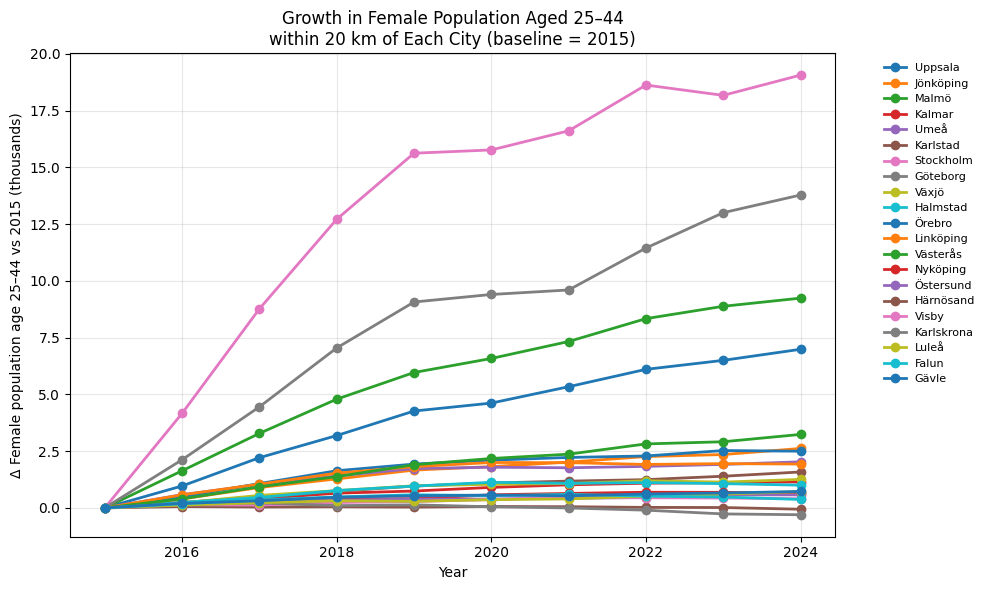

In [34]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 0. Prepare df_all_3006 & city buffers (skip if already loaded)
# ----------------------------------------------------
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "geoparquet"
merged_path = DATA_DIR / "befolkning_1km_2015_2024.parquet"

# Load merged GeoParquet file only if not loaded before
if "df_all" not in globals():
    df_all = gpd.read_parquet(merged_path).copy()

# Ensure CRS is WGS84
df_all = df_all.set_crs(4326)

# Standardize total population column
if "total_pop" in df_all.columns:
    df_all["total_pop"] = df_all["total_pop"]
elif "beftotalt" in df_all.columns:
    df_all["total_pop"] = df_all["beftotalt"]
else:
    df_all["total_pop"] = df_all["kvinna"] + df_all["man"]

# Reproject to SWEREF 3006 (if not already done)
if "df_all_3006" not in globals():
    df_all_3006 = df_all.to_crs(3006)

# Build city buffers if not already created
if "gdf_cities_3006" not in globals():
    cities = {
        "Uppsala":    (17.6389, 59.8586),
        "Jönköping":  (14.1618, 57.7826),
        "Malmö":      (13.0038, 55.6050),
        "Kalmar":     (16.3568, 56.6634),
        "Umeå":       (20.2653, 63.8258),
        "Karlstad":   (13.5036, 59.4022),
        "Stockholm":  (18.0686, 59.3293),
        "Göteborg":   (11.9746, 57.7089),
        "Växjö":      (14.8059, 56.8790),
        "Halmstad":   (12.8590, 56.6745),
        "Örebro":     (15.2134, 59.2753),
        "Linköping":  (15.6216, 58.4109),
        "Västerås":   (16.5448, 59.6099),
        "Nyköping":   (17.0079, 58.7530),
        "Östersund":  (14.6357, 63.1792),
        "Härnösand":  (17.9400, 62.6323),
        "Visby":      (18.2920, 57.6348),
        "Karlskrona": (15.5866, 56.1616),
        "Luleå":      (22.1567, 65.5848),
        "Falun":      (15.6350, 60.6074),
        "Gävle":      (17.1413, 60.6749),
    }
    city_names = list(cities.keys())
    RADIUS_KM = 20
    RADIUS_M = RADIUS_KM * 1000

    gdf_cities = gpd.GeoDataFrame(
        {"city": city_names},
        geometry=[Point(lon, lat) for lon, lat in cities.values()],
        crs=4326,
    ).to_crs(3006)

    # Replace points with 20 km buffers
    gdf_cities["geometry"] = gdf_cities.geometry.buffer(RADIUS_M)
    gdf_cities_3006 = gdf_cities
else:
    city_names = list(gdf_cities_3006["city"].values)

# ----------------------------------------------------
# 1. Approximate female population for each age segment (1 km grids)
# ----------------------------------------------------
AGE_15_24_COLS = ["ald15_20", "ald20_25"]
AGE_25_44_COLS = ["ald25_30", "ald30_35", "ald35_40", "ald40_45"]

g = df_all_3006.copy()

# Female share across total population
g["female_share"] = g["kvinna"] / g["total_pop"].replace(0, np.nan)

# Total population by age segment
g["age_15_24_total"] = g[AGE_15_24_COLS].sum(axis=1)
g["age_25_44_total"] = g[AGE_25_44_COLS].sum(axis=1)

# Approximation: female population in each age band = age_total × female share
g["female_15_24"] = g["age_15_24_total"] * g["female_share"]
g["female_25_44"] = g["age_25_44_total"] * g["female_share"]

# ----------------------------------------------------
# 2. Spatial join to city buffers and aggregate by city-year
# ----------------------------------------------------
joined = gpd.sjoin(
    g[["geometry", "year", "female_15_24", "female_25_44"]],
    gdf_cities_3006[["city", "geometry"]],
    how="inner",
    predicate="within",
)

city_age = (
    joined.groupby(["city", "year"])[["female_15_24", "female_25_44"]]
          .sum()
          .reset_index()
          .sort_values(["city", "year"])
)

# ----------------------------------------------------
# 3. Plotting function for female age-segment growth
# ----------------------------------------------------
def plot_female_growth(city_age_df, col_name, age_label, filename):
    YEARS = sorted(city_age_df["year"].unique())
    YEAR0 = min(YEARS)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot a line for each city
    for city in city_names:
        df_city = city_age_df[city_age_df["city"] == city].sort_values("year")
        if df_city.empty:
            continue

        # Change from baseline (in thousands)
        base = float(df_city.loc[df_city["year"] == YEAR0, col_name].iloc[0])
        df_city["delta_thousands"] = (df_city[col_name] - base) / 1000.0

        ax.plot(
            df_city["year"],
            df_city["delta_thousands"],
            marker="o",
            linewidth=2,
            label=city,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Δ Female population age {age_label} vs {YEAR0} (thousands)")
    ax.set_title(
        f"Growth in Female Population Aged {age_label}\n"
        f"within 20 km of Each City (baseline = {YEAR0})"
    )
    ax.grid(True, alpha=0.3)

    # Legend placed outside for readability
    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        frameon=False,
    )

    plt.tight_layout()

    if filename is not None:
        out_path = PROJECT_ROOT / "figures" / filename
        out_path.parent.mkdir(exist_ok=True, parents=True)
        plt.savefig(out_path, dpi=300)
        print("✅ saved:", out_path)

    plt.show()

# ----------------------------------------------------
# 4. Generate both figures
# ----------------------------------------------------
plot_female_growth(
    city_age,
    col_name="female_15_24",
    age_label="15–24",
    filename="Female growth 15–24 (within 20km).png",
)

plot_female_growth(
    city_age,
    col_name="female_25_44",
    age_label="25–44",
    filename="Female growth 25–44 (within 20km).png",
)


In [ ]:
########

In [19]:
import geopandas as gpd
path = DATA_DIR / "befolkning_1km_2024.parquet"
gdf = gpd.read_parquet(path)
[col for col in gdf.columns if "man" in col.lower() or "kvin" in col.lower()]


['kvinna', 'man']